In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

In [ ]:
df=pd.read_csv('/content/breast-cancer.csv')
df=df.drop(['id','Unnamed: 32'],axis=1)
df['diagnosis']=df['diagnosis'].map({'M':0,'B':1}).astype(int)
df.sample(10)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
422,1,11.61,16.02,75.46,408.2,0.10880,0.11680,0.07097,0.044970,0.1886,...,12.64,19.67,81.93,475.7,0.14150,0.21700,0.23020,0.11050,0.2787,0.07427
323,0,20.34,21.51,135.90,1264.0,0.11700,0.18750,0.25650,0.150400,0.2569,...,25.30,31.86,171.10,1938.0,0.15920,0.44920,0.53440,0.26850,0.5558,0.10240
474,1,10.88,15.62,70.41,358.9,0.10070,0.10690,0.05115,0.015710,0.1861,...,11.94,19.35,80.78,433.1,0.13320,0.38980,0.33650,0.07966,0.2581,0.10800
483,1,13.70,17.64,87.76,571.1,0.09950,0.07957,0.04548,0.031600,0.1732,...,14.96,23.53,95.78,686.5,0.11990,0.13460,0.17420,0.09077,0.2518,0.06960
487,0,19.44,18.82,128.10,1167.0,0.10890,0.14480,0.22560,0.119400,0.1823,...,23.96,30.39,153.90,1740.0,0.15140,0.37250,0.59360,0.20600,0.3266,0.09009
354,1,11.14,14.07,71.24,384.6,0.07274,0.06064,0.04505,0.014710,0.1690,...,12.12,15.82,79.62,453.5,0.08864,0.12560,0.12010,0.03922,0.2576,0.07018
297,0,11.76,18.14,75.00,431.1,0.09968,0.05914,0.02685,0.035150,0.1619,...,13.36,23.39,85.10,553.6,0.11370,0.07974,0.06120,0.07160,0.1978,0.06915
425,1,10.03,21.28,63.19,307.3,0.08117,0.03912,0.00247,0.005159,0.1630,...,11.11,28.94,69.92,376.3,0.11260,0.07094,0.01235,0.02579,0.2349,0.08061
438,1,13.85,19.60,88.68,592.6,0.08684,0.06330,0.01342,0.022930,0.1555,...,15.63,28.01,100.90,749.1,0.11180,0.11410,0.04753,0.05890,0.2513,0.06911
122,0,24.25,20.20,166.20,1761.0,0.14470,0.28670,0.42680,0.201200,0.2655,...,26.02,23.99,180.90,2073.0,0.16960,0.42440,0.58030,0.22480,0.3222,0.08009


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.iloc[:,1:],df.iloc[:,0],test_size=0.2,random_state=42)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.svm import SVC

from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

In [ ]:
def knn(x_train,x_test,y_train,y_test):
  global knn_reg
  global knn_pred
  knn_reg=KNeighborsClassifier(n_neighbors=5)
  knn_reg.fit(x_train,y_train)
  knn_pred=knn_reg.predict(x_test)
  print(confusion_matrix(y_test,knn_pred))
  print(accuracy_score(y_test,knn_pred))
  print(classification_report(y_test,knn_pred))

In [ ]:
def nb(x_train,x_test,y_train,y_test):
  global nb_reg
  global nb_pred
  nb_reg=GaussianNB()
  nb_reg.fit(x_train,y_train)
  nb_pred=nb_reg.predict(x_test)
  print(confusion_matrix(y_test,nb_pred))
  print(accuracy_score(y_test,nb_pred))
  print(classification_report(y_test,nb_pred))

In [ ]:
def lr(x_train,x_test,y_train,y_test):
  global lr_reg
  global lr_pred
  lr_reg=LogisticRegression()
  lr_reg.fit(x_train,y_train)
  lr_pred=lr_reg.predict(x_test)
  print(confusion_matrix(y_test,lr_pred))
  print(accuracy_score(y_test,lr_pred))
  print(classification_report(y_test,lr_pred))

In [ ]:
def dt(x_train,x_test,y_train,y_test):
  global dt_reg
  global dt_pred
  dt_reg=DecisionTreeClassifier(criterion='entropy')
  dt_reg.fit(x_train,y_train)
  dt_pred=dt_reg.predict(x_test)
  print(confusion_matrix(y_test,dt_pred))
  print(accuracy_score(y_test,dt_pred))
  print(classification_report(y_test,dt_pred))

In [ ]:
def rf(x_train,x_test,y_train,y_test):
  global rf_reg
  global rf_pred
  rf_reg=RandomForestClassifier(criterion='entropy',n_estimators=5)
  rf_reg.fit(x_train,y_train)
  rf_pred=dt_reg.predict(x_test)
  print(confusion_matrix(y_test,rf_pred))
  print(accuracy_score(y_test,rf_pred))
  print(classification_report(y_test,rf_pred))

In [ ]:
def adab(x_train,x_test,y_train,y_test):
  global adab_reg
  global adab_pred
  lr=LogisticRegression()
  adab_reg=AdaBoostClassifier(estimator=lr,n_estimators=5)
  adab_reg.fit(x_train,y_train)
  adab_pred=dt_reg.predict(x_test)
  print(confusion_matrix(y_test,adab_pred))
  print(accuracy_score(y_test,adab_pred))
  print(classification_report(y_test,adab_pred))

In [ ]:
def gb(x_train,x_test,y_train,y_test):
  global gb_reg
  global gb_pred
  gb_reg=GradientBoostingClassifier(n_estimators=5)
  gb_reg.fit(x_train,y_train)
  gb_pred=gb_reg.predict(x_test)
  print(confusion_matrix(y_test,gb_pred))
  print(accuracy_score(y_test,gb_pred))
  print(classification_report(y_test,gb_pred))

In [ ]:
def xgb(x_train,x_test,y_train,y_test):
  global xgb_reg
  global xgb_pred
  xgb_reg=XGBClassifier(n_estimators=5)
  xgb_reg.fit(x_train,y_train)
  xgb_pred=dt_reg.predict(x_test)
  print(confusion_matrix(y_test,xgb_pred))
  print(accuracy_score(y_test,xgb_pred))
  print(classification_report(y_test,xgb_pred))

In [ ]:
def svm(x_train,x_test,y_train,y_test):
  global svm_reg
  global svm_pred
  svm_reg=SVC(kernel='rbf')   # Radial Basis Function. (where separation becomes possible.) non linear to linear
  svm_reg.fit(x_train,y_train)
  svm_pred=dt_reg.predict(x_test)
  print(confusion_matrix(y_test,svm_pred))
  print(accuracy_score(y_test,svm_pred))
  print(classification_report(y_test,svm_pred))

In [ ]:
def common(x_train,x_test,y_train,y_test):
  print('------knn------')
  knn(x_train,x_test,y_train,y_test)
  print('-----nb-----')
  nb(x_train,x_test,y_train,y_test)
  print('------lr-----')
  lr(x_train,x_test,y_train,y_test)
  print('----dt-----')
  dt(x_train,x_test,y_train,y_test)
  print('-----rf------')
  rf(x_train,x_test,y_train,y_test)
  print('------adab------')
  adab(x_train,x_test,y_train,y_test)
  print('-------gb------')
  gb(x_train,x_test,y_train,y_test)
  print('-----xgb------')
  xgb(x_train,x_test,y_train,y_test)
  print('------svm-----')
  svm(x_train,x_test,y_train,y_test)

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
common(x_train,x_test,y_train,y_test)

------knn------
[[38  5]
 [ 0 71]]
0.956140350877193
              precision    recall  f1-score   support

           0       1.00      0.88      0.94        43
           1       0.93      1.00      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114

-----nb-----
[[40  3]
 [ 0 71]]
0.9736842105263158
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        43
           1       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

------lr-----
[[39  4]
 [ 1 70]]
0.956140350877193
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy               

# AUC & ROC

In [ ]:
# Area under the curve
# ROC (Rectifier Operating Characterstic)

In [ ]:
from sklearn.metrics import roc_auc_score,roc_curve

In [ ]:
knn_fpr,knn_tpr,knn_th=roc_curve(y_test,knn_pred)
nb_fpr,nb_tpr,nb_th=roc_curve(y_test,nb_pred)
lr_fpr,lr_tpr,lr_th=roc_curve(y_test,lr_pred)
dt_fpr,dt_tpr,dt_th=roc_curve(y_test,dt_pred)

rf_fpr,rf_tpr,rf_th=roc_curve(y_test,rf_pred)
adab_fpr,adab_tpr,adab_th=roc_curve(y_test,adab_pred)
gb_fpr,gb_tpr,gb_th=roc_curve(y_test,gb_pred)
xgb_fpr,xgb_tpr,xgb_th=roc_curve(y_test,xgb_pred)

svm_fpr,svm_tpr,svm_th=roc_curve(y_test,svm_pred)

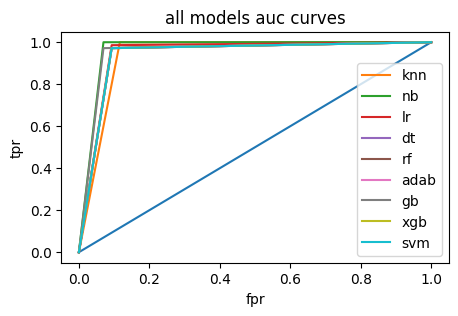

In [ ]:
plt.figure(figsize=(5,3))
plt.plot([0, 1], [0, 1])
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('all models auc curves')

plt.plot(knn_fpr,knn_tpr,label='knn')
plt.plot(nb_fpr,nb_tpr,label='nb')
plt.plot(lr_fpr,lr_tpr,label='lr')
plt.plot(dt_fpr,dt_tpr,label='dt')

plt.plot(rf_fpr,rf_tpr,label='rf')
plt.plot(adab_fpr,adab_tpr,label='adab')
plt.plot(gb_fpr,gb_tpr,label='gb')
plt.plot(xgb_fpr,xgb_tpr,label='xgb')

plt.plot(svm_fpr,svm_tpr,label='svm')

plt.legend(loc = 0)
plt.show()


  #What does loc=0 mean?
  #loc=0 means “let Matplotlib automatically choose the best location” for the legend
  #so that it doesn’t cover important parts of the graph.

From ALL Models we are going to finalize the Mode called Random Forest|

Since we selected the Random Forest as a Best Model now we can Improve a Lot using Hyperparameter tuning techniques

#cross validation

In [ ]:
x=df.iloc[:,1:]
y=df.iloc[:,0]

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(criterion='entropy',n_estimators=5)
result=cross_val_score(rf,x,y,cv=10)
result

array([0.96491228, 0.87719298, 0.9122807 , 0.96491228, 1.        ,
       0.98245614, 0.9122807 , 0.98245614, 0.96491228, 0.98214286])

In [ ]:
print(len(result))

10


In [ ]:
print(f'test accuracy by cross validation {result.mean()}')

test accuracy by cross validation 0.9543546365914788


#Hyper Parameter Tuning Techniques

Selecting the Best Parameters for the Model based on the data

There are 2 types of Parameters

        - `GridSearch CV`
        - `Randomised Search CV

In [ ]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

In [ ]:
parameters_list={'n_estimators' : [5,10,15,20,25] ,
                   'criterion' : ['gini' , 'entropy'] ,
                   'max_depth' : [2,3,4,5,6,7] ,
                   'class_weight':[None,"balanced", "balanced_subsample"],
                   }
rf=RandomForestClassifier()

rand_reg=RandomizedSearchCV(estimator=rf,
                        param_distributions=parameters_list,
                        scoring='accuracy',cv=10)
rand_results=rand_reg.fit(x,y)

In [ ]:
parameters_list={'n_estimators' : [5,10,15,20,25] ,
                   'criterion' : ['gini' , 'entropy'] ,
                   'max_depth' : [2,3,4,5,6,7] ,
                   'class_weight':[None,"balanced", "balanced_subsample"],
                   }
rf=RandomForestClassifier()

grid_reg=GridSearchCV(estimator=rf,    # use only grid search
                      param_grid=parameters_list,
                      scoring='accuracy',cv=10)
rand_results=grid_reg.fit(x,y)

In [ ]:
print(grid_reg.best_params_)   # use only grid search parameters

{'class_weight': 'balanced_subsample', 'criterion': 'entropy', 'max_depth': 7, 'n_estimators': 20}


In [ ]:
print(rand_reg.best_params_)

{'n_estimators': 25, 'max_depth': 6, 'criterion': 'gini', 'class_weight': 'balanced_subsample'}


In [ ]:
rf_reg = RandomForestClassifier(n_estimators=25,
                                max_depth=6,
                                criterion = 'entropy',
                                class_weight='balanced')
rf_reg.fit(x_train,y_train)

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=6, n_estimators=25)

In [ ]:
ans=rf_reg.predict(x_test)

In [ ]:
print(f'test accuracy with best parameters {accuracy_score(y_test,ans)}')

test accuracy with best parameters 0.9649122807017544


# saving model

In [ ]:
import pickle

In [ ]:
with open('allmodel.pkl','wb') as f:
  pickle.dump(rf_reg,f)

#Data balancing

In [ ]:
t=pd.DataFrame({'H:Rate': [70,48,30,20,10,20,30,40,50,70],
                  'BP:Rate':[120,90,99,80,120,70,90,110,100,10],
                  'Status':[1,0,0,0,0,0,0,0,1,0]
                  })
t

,H:Rate,BP:Rate,Status
0,70,120,1
1,48,90,0
2,30,99,0
3,20,80,0
4,10,120,0
5,20,70,0
6,30,90,0
7,40,110,0
8,50,100,1
9,70,10,0


In [ ]:
x=t.iloc[:,:-1]
y=t.iloc[:,-1]

In [ ]:
!pip install imblearn

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
print(f'No of rows {1} for alive patients {sum(t['Status']==1)}')
print(f'No of rows {0} for died patients {sum(t['Status']==0)}')

smote_reg=SMOTE(random_state=2,k_neighbors=1)
balanced_inde,balance_dep=smote_reg.fit_resample(x,y)

print(f'No of rows {1} for alive patients {sum(balance_dep==1)}')
print(f'No of rows {0} for died patients {sum(balance_dep==0)}')

No of rows 1 for alive patients 2
No of rows 0 for died patients 8
No of rows 1 for alive patients 8
No of rows 0 for died patients 8


In [ ]:
balanced_inde

,H:Rate,BP:Rate
0,70,120
1,48,90
2,30,99
3,20,80
4,10,120
5,20,70
6,30,90
7,40,110
8,50,100
9,70,10
